In [61]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [62]:
kk = pd.read_csv('Life_Expectancy.csv')

In [63]:
kk.head(20)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [64]:
kk.tail(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2928,Zimbabwe,2009,Developing,50.0,587.0,30,4.64,1.040021,73.0,853,...,69.0,6.26,73.0,18.1,65.824121,1381599.0,7.5,7.4,0.419,9.9
2929,Zimbabwe,2008,Developing,48.2,632.0,30,3.56,20.843429,75.0,0,...,75.0,4.96,75.0,20.5,325.678573,13558469.0,7.8,7.8,0.421,9.7
2930,Zimbabwe,2007,Developing,46.6,67.0,29,3.88,29.814566,72.0,242,...,73.0,4.47,73.0,23.7,396.998217,1332999.0,8.2,8.2,0.414,9.6
2931,Zimbabwe,2006,Developing,45.4,7.0,28,4.57,34.262169,68.0,212,...,71.0,5.12,7.0,26.8,414.796232,13124267.0,8.6,8.6,0.408,9.5
2932,Zimbabwe,2005,Developing,44.6,717.0,28,4.14,8.717409,65.0,420,...,69.0,6.44,68.0,30.3,444.765750,129432.0,9.0,9.0,0.406,9.3
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.000000,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


In [65]:
kk.shape

(2938, 22)

In [66]:
kk.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [67]:
kk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [68]:
print(f'Number of duplicae')

Number of duplicae


In [69]:
# checking for missing values 
print(kk.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


In [70]:
# Handling those missing Values
for column in kk.columns:
    if kk[column].dtype == 'object':  
       # categorical column
       kk[column].fillna(kk[column].mode()[0], inplace=True)
    else: # Numerical colum

       kk[column].fillna(kk[column].median(), inplace=True)

# verify that there are no more missing vales
print(kk.isnull().sum())

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64


In [71]:
kk.head(20)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [72]:
kk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2938 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

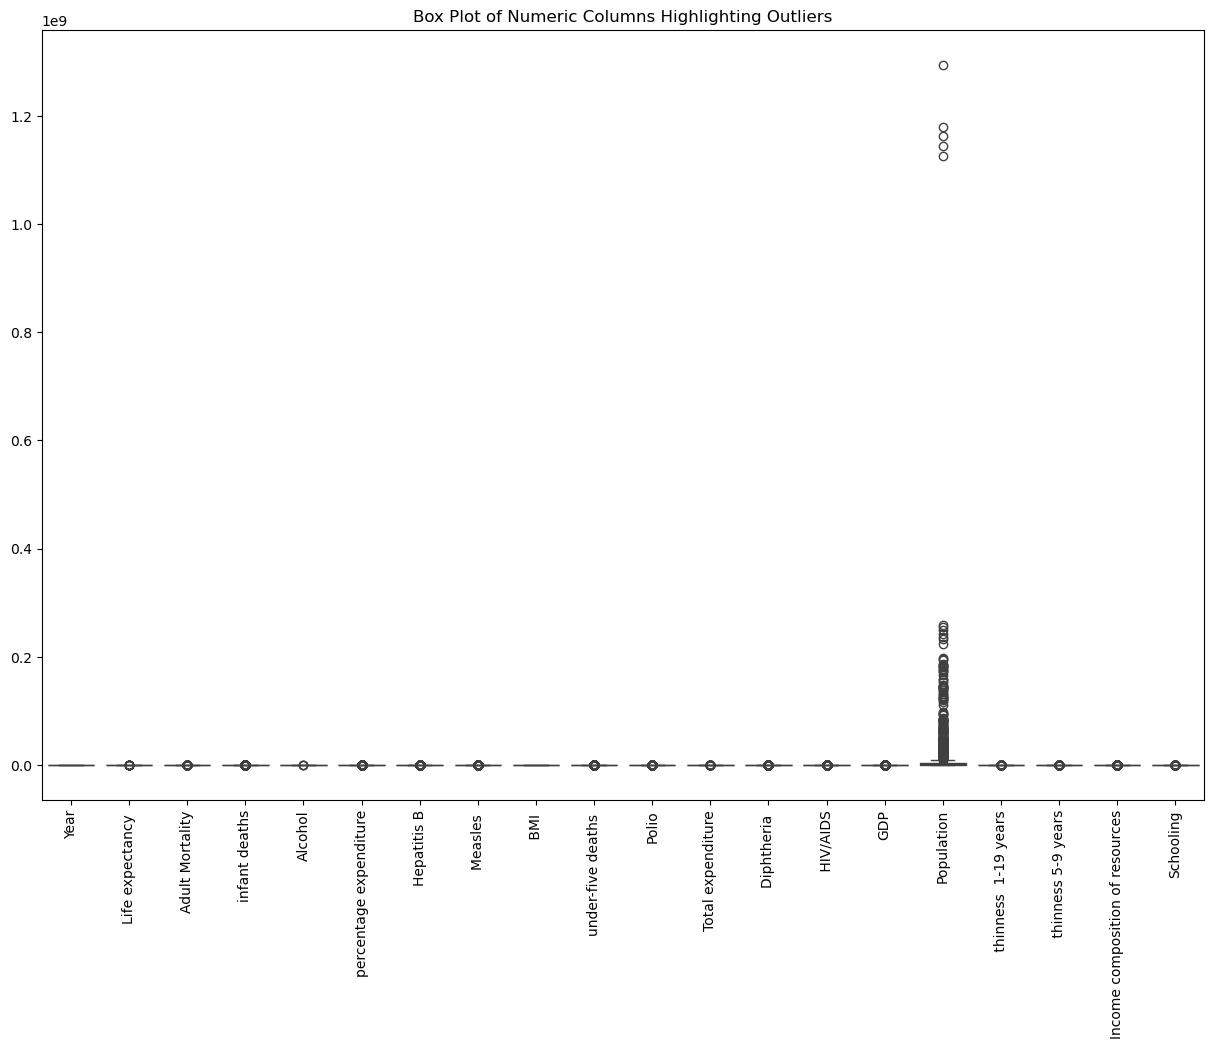

In [73]:
# Checking for Outliers
# Visualizing Outliers using Box Plots
plt.figure(figsize=(15, 10))
sns.boxplot(data=kk.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title('Box Plot of Numeric Columns Highlighting Outliers')
plt.show()

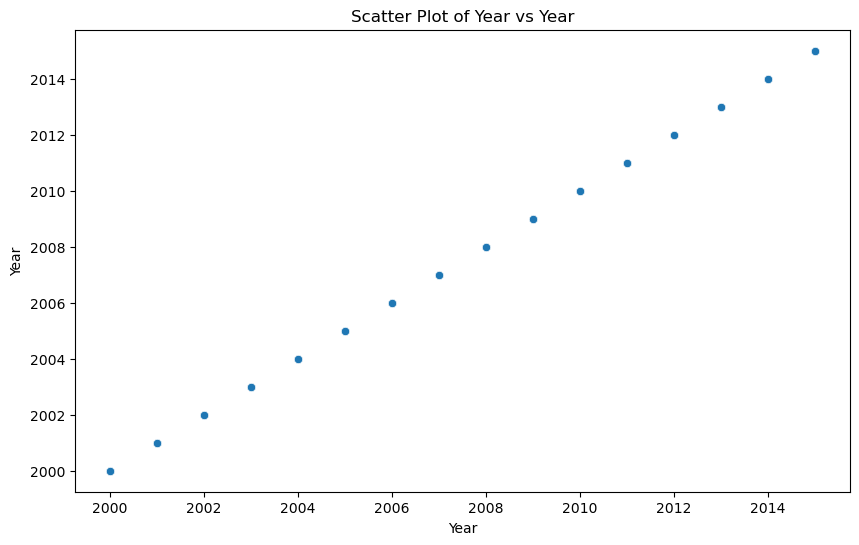

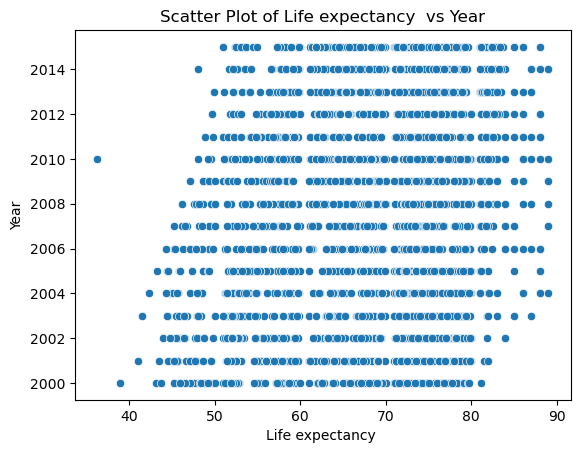

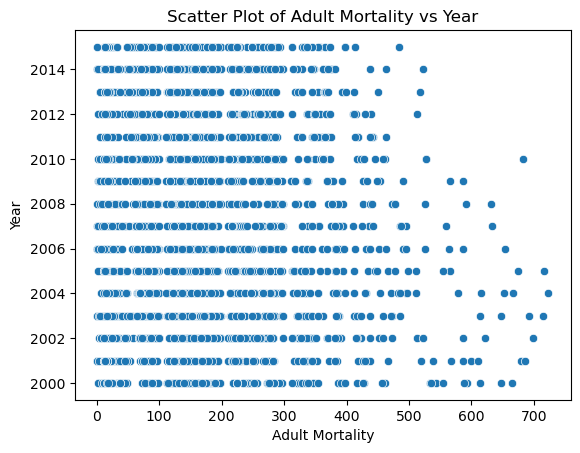

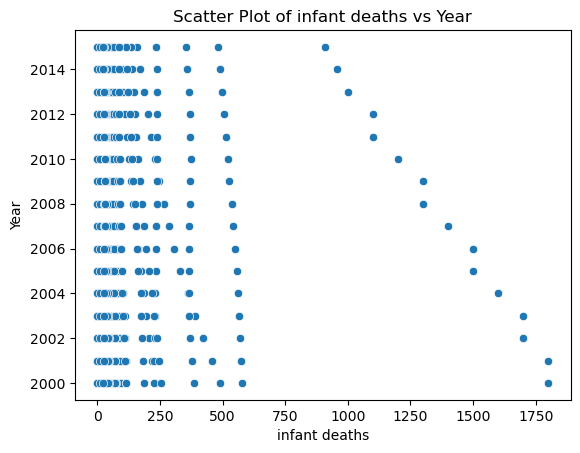

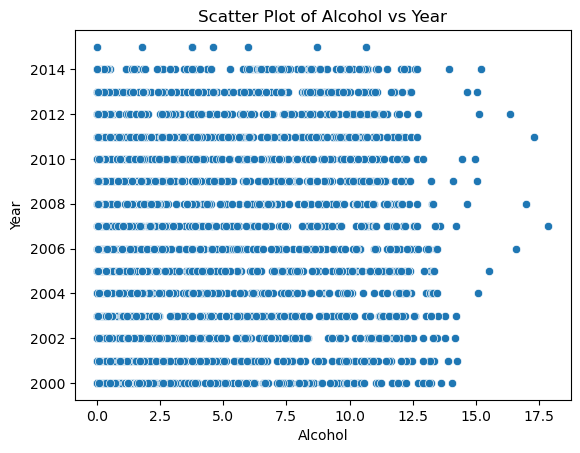

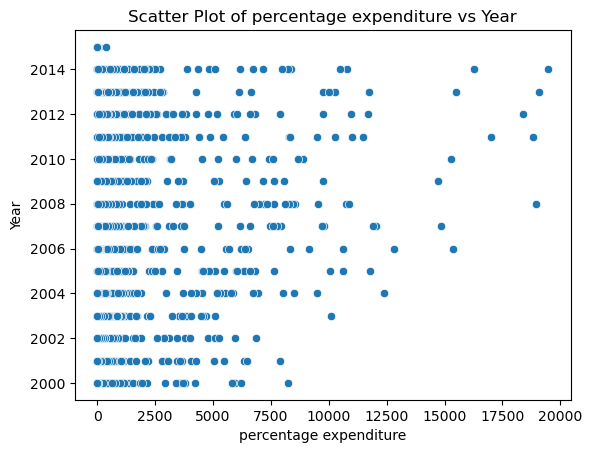

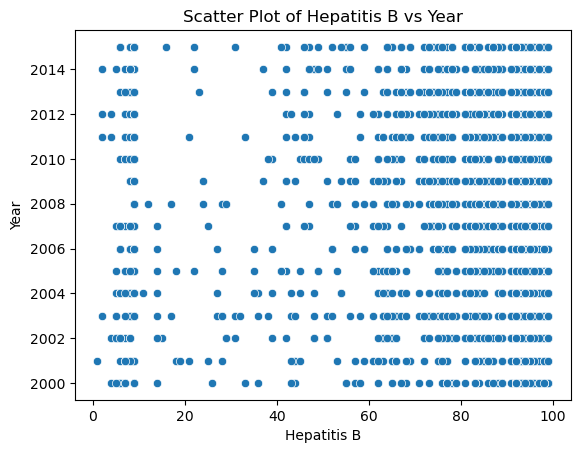

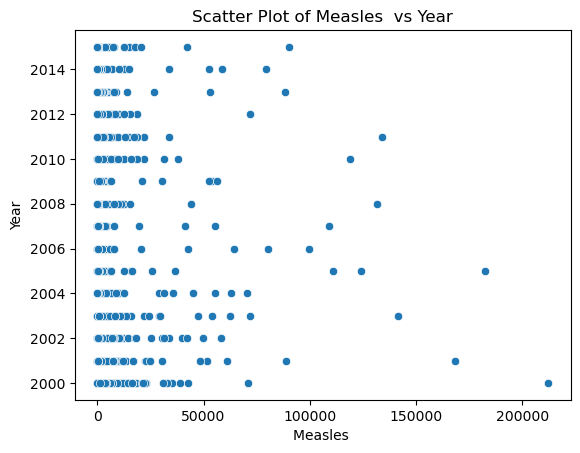

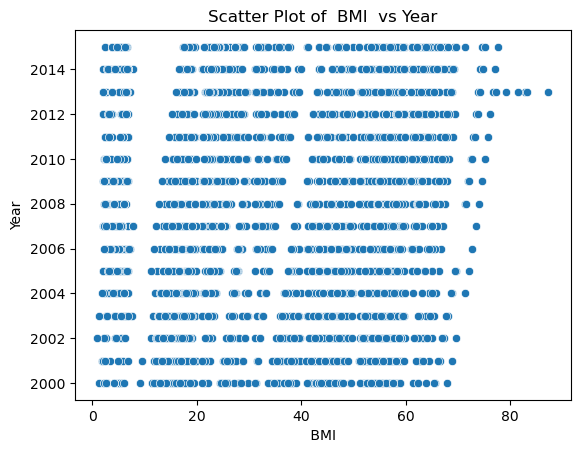

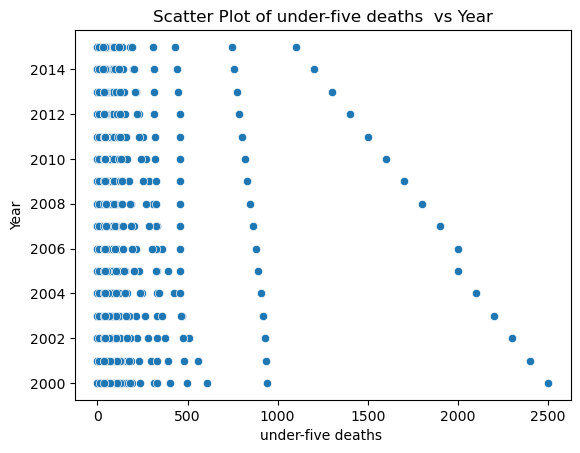

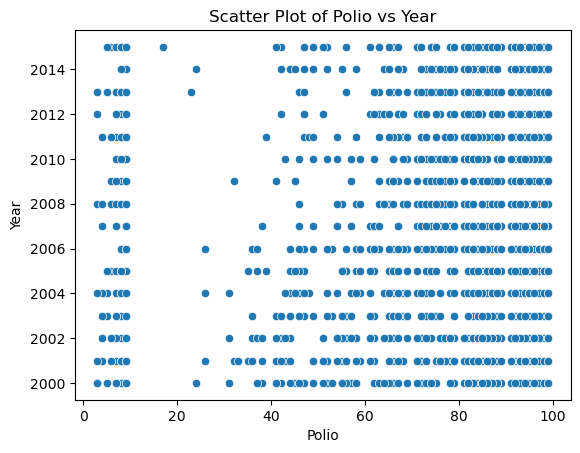

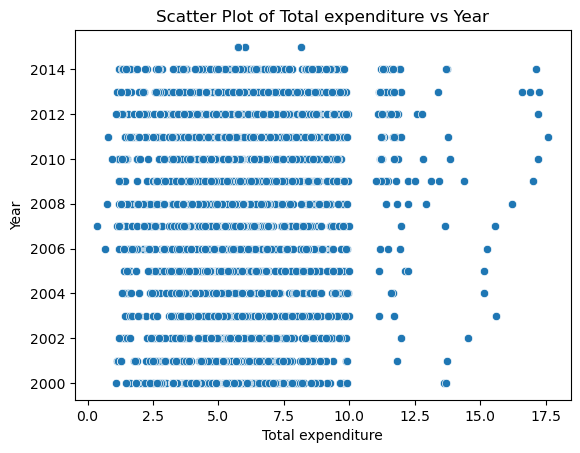

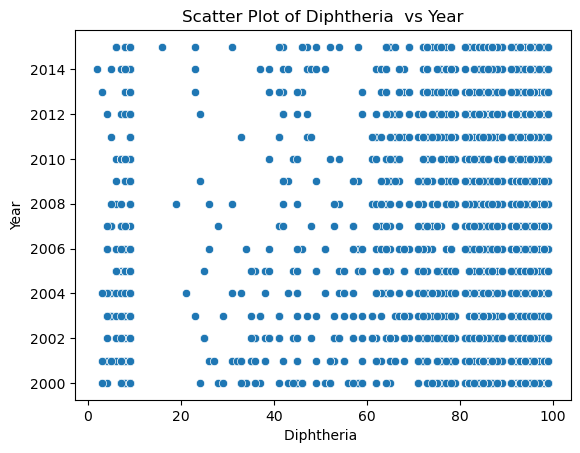

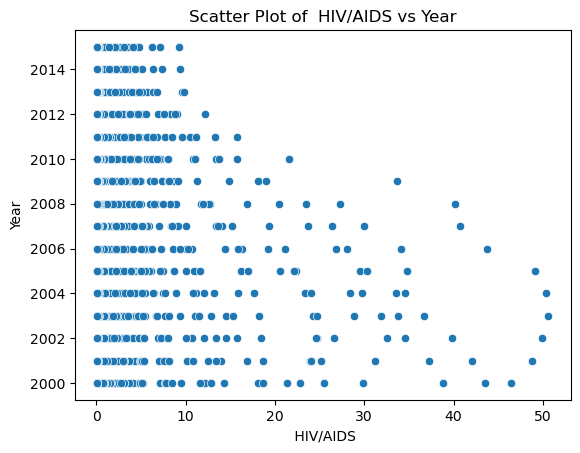

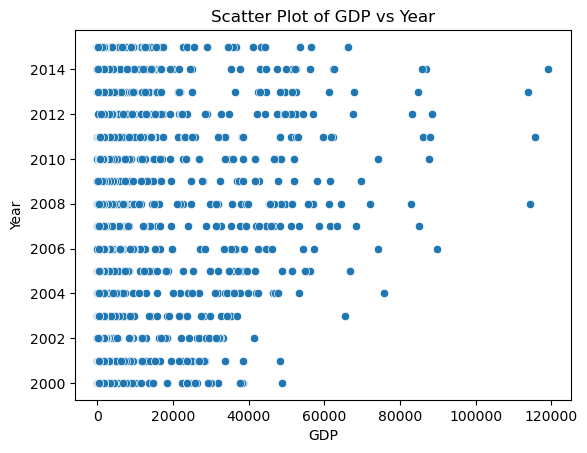

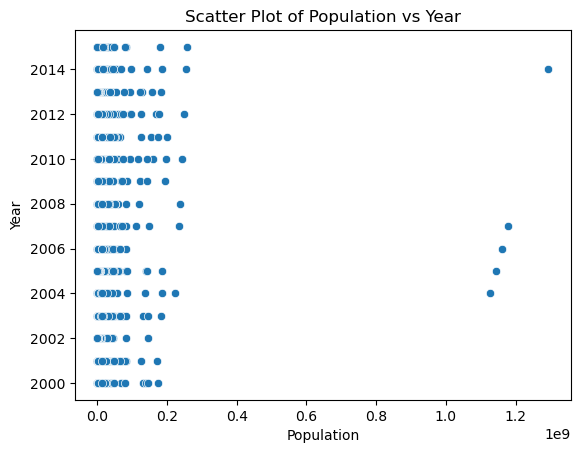

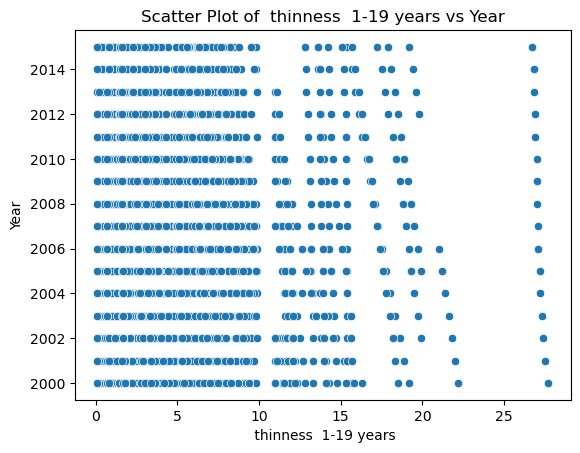

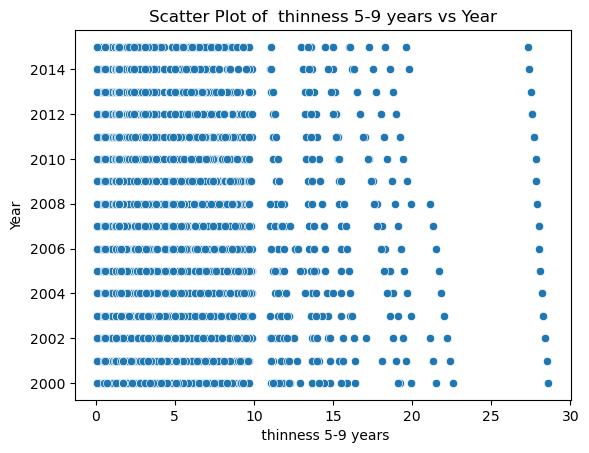

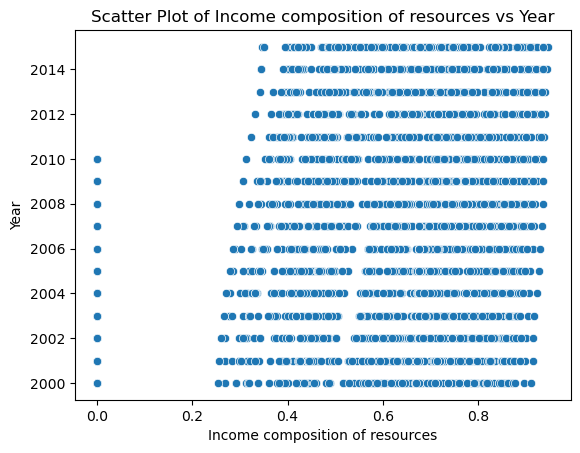

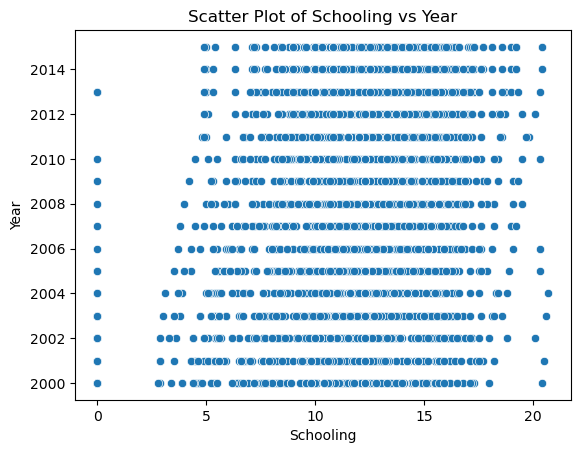

In [74]:
# Visualizing Outliers using Scatter Plot for pairs of features
# You can choose relevant pairs based on your dataset
plt.figure(figsize=(10, 6))
for column in kk.select_dtypes(include='number').columns:
    sns.scatterplot(data=kk, x=column, y=kk.select_dtypes(include='number').columns[0],)
    plt.title(f'Scatter Plot of {column} vs {kk.select_dtypes(include="number").columns[0]}')
    plt.show()

In [75]:
# Identifying the outliers using the IQR manual method
def manual_iqr(kk):
    Q1 = kk.quantile(0.25)
    Q3 = kk.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((kk < lower_bound) | (kk > upper_bound)).any(axis=1)
    return kk[outliers_iqr]

# identify outliers using manual method
kk_outliers_iqr = manual_iqr(kk.select_dtypes(include='number'))
print("Number of outliers detected using manual IQR method: ",
kk_outliers_iqr.shape[0])

# Display outliers 
print("outliers detected using manual IQR method: ")
print(kk_outliers_iqr)

Number of outliers detected using manual IQR method:  1880
outliers detected using manual IQR method: 
      Year  Life expectancy   Adult Mortality  infant deaths  Alcohol  \
0     2015              65.0            263.0             62     0.01   
1     2014              59.9            271.0             64     0.01   
2     2013              59.9            268.0             66     0.01   
3     2012              59.5            272.0             69     0.01   
4     2011              59.2            275.0             71     0.01   
...    ...               ...              ...            ...      ...   
2933  2004              44.3            723.0             27     4.36   
2934  2003              44.5            715.0             26     4.06   
2935  2002              44.8             73.0             25     4.43   
2936  2001              45.3            686.0             25     1.72   
2937  2000              46.0            665.0             24     1.68   

      percentage exp

In [76]:
def Outliers():
     for columns in kk.select_dtypes(include = ['float64' , 'int64']).columns:
        Mean = np.mean(kk[columns])
        Std = np.std(kk[columns])
        z = ((kk[columns] - Mean)/ Std)
        Threshold = 3
        outliers = np.where((np.abs(z) > Threshold) | (np.abs(z) < -Threshold))[0]
        kk_outliers = outliers
        print(kk_outliers)
Outliers()

[]
[1127 2312]
[ 346  347  348  349  350  351  865 1127 1480 1481 1482 1483 1484 1485
 1486 1487 1488 1489 1578 1579 1581 1582 1584 1585 2498 2502 2503 2728
 2729 2916 2917 2920 2921 2928 2929 2932 2933 2934 2936 2937]
[ 572  573  574  575 1186 1187 1188 1189 1190 1191 1192 1193 1194 1195
 1196 1197 1198 1199 1200 1201 1893 1894 1895 1896 1897 1898 1899 1900
 1901 1902 1903 1904 1905 1906 1907 1908 1957]
[227 228 873 874 875]
[ 113  114  115  116  117  118  119  129  131  132  133  134  135  136
  241  247  498  499  501  503  504  738  739  741  743  744  745  747
  748  931  937  999 1000 1001 1002 1171 1173 1177 1178 1180 1181 1256
 1257 1258 1259 1261 1318 1321 1324 1325 1539 1540 1542 1545 1547 1549
 1550 1552 1553 1836 1837 1838 1847 1849 1852 1915 1918 1919 1920 2314
 2508 2509 2512 2513 2522 2523 2524 2525 2527 2529 2530 2531 2532 2534]
[  40   41   87  149  155  157  167  203  204  239  253  254  255  275
  282  316  326  329  348  403  434  446  452  461  473  486  499  500
 

In [77]:
# Function to identify and treat outliers for numerical columns
def treat_numerical_outliers(kk, column):
    Q1 = kk[column].quantile(0.25)
    Q3 = kk[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers
    kk[column] = kk[column].clip(lower=lower_bound, upper=upper_bound)

# Function to treat outliers for categorical columns
def treat_categorical_outliers(kk, column):
    # Find the top categories
    top_categories = kk[column].value_counts().nlargest(10).index
    
    # Replace rare categories with 'Other'
    kk[column] = kk[column].apply(lambda x: x if x in top_categories else 'Other')

# Apply the functions to each column in the dataframe using a for loop
for col in kk.columns:
    if kk[col].dtype in ['int64', 'float64']:  # Numeric columns
        treat_numerical_outliers(kk, col)
    elif kk[col].dtype == 'object':  # Categorical columns
        treat_categorical_outliers(kk, col)

# Save the treated dataframe back to CSV
kk.to_csv('treated_data.csv', index=False)

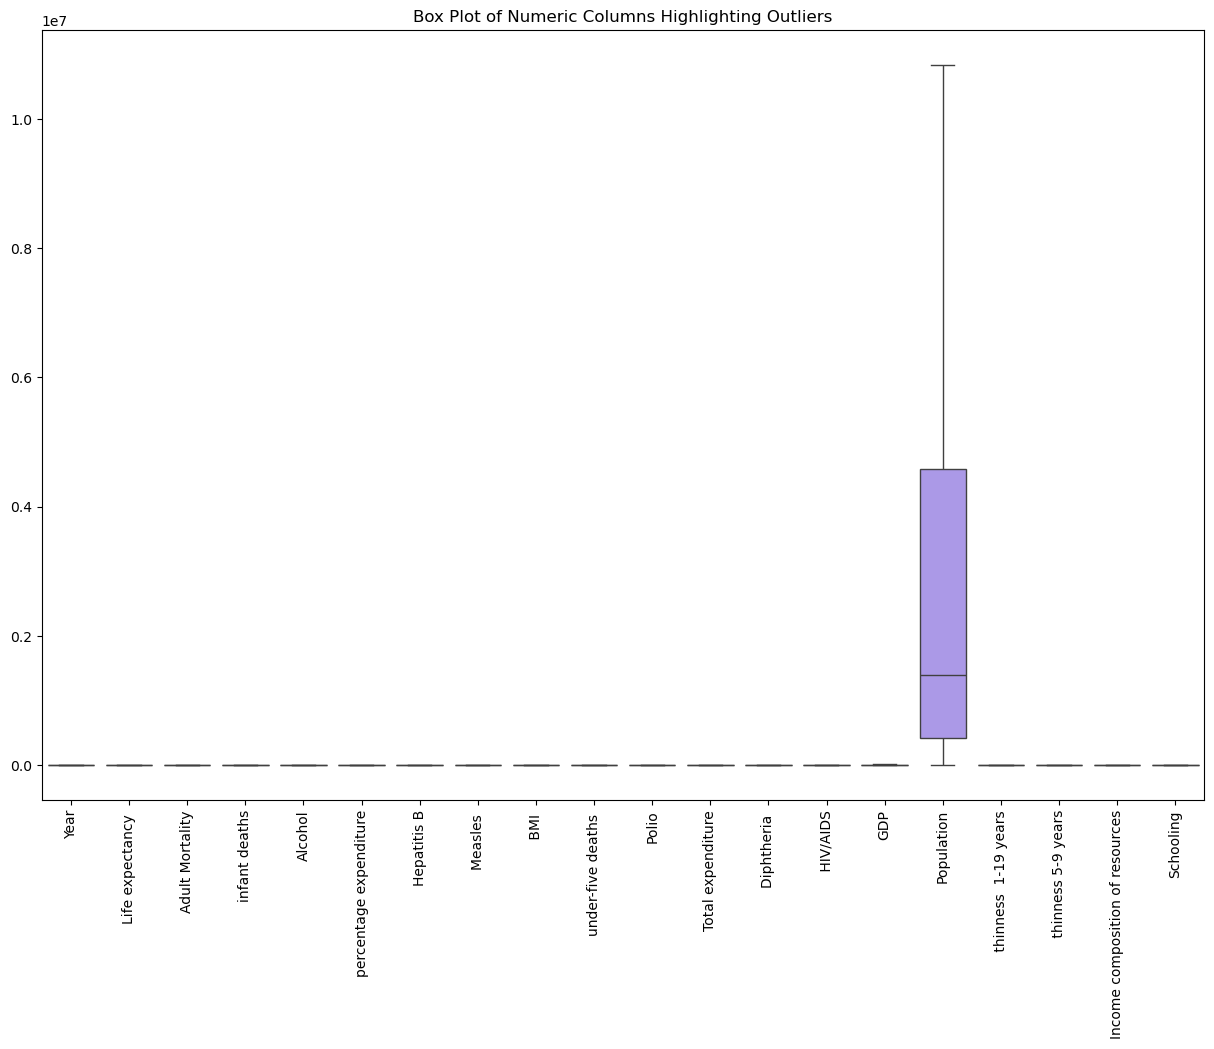

In [78]:
# Checking for Outliers
# Visualizing Outliers using Box Plots
plt.figure(figsize=(15, 10))
sns.boxplot(data=kk.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title('Box Plot of Numeric Columns Highlighting Outliers')
plt.show()

In [79]:
# Identifying the outliers using the IQR manual method
def manual_iqr(kk):
    Q1 = kk.quantile(0.25)
    Q3 = kk.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((kk < lower_bound) | (kk > upper_bound)).any(axis=1)
    return kk[outliers_iqr]

# identify outliers using manual method
kk_outliers_iqr = manual_iqr(kk.select_dtypes(include='number'))
print("Number of outliers detected using manual IQR method: ",
kk_outliers_iqr.shape[0])

# Display outliers 
print("outliers detected using manual IQR method: ")
print(kk_outliers_iqr)

Number of outliers detected using manual IQR method:  0
outliers detected using manual IQR method: 
Empty DataFrame
Columns: [Year, Life expectancy , Adult Mortality, infant deaths, Alcohol, percentage expenditure, Hepatitis B, Measles ,  BMI , under-five deaths , Polio, Total expenditure, Diphtheria ,  HIV/AIDS, GDP, Population,  thinness  1-19 years,  thinness 5-9 years, Income composition of resources, Schooling]
Index: []


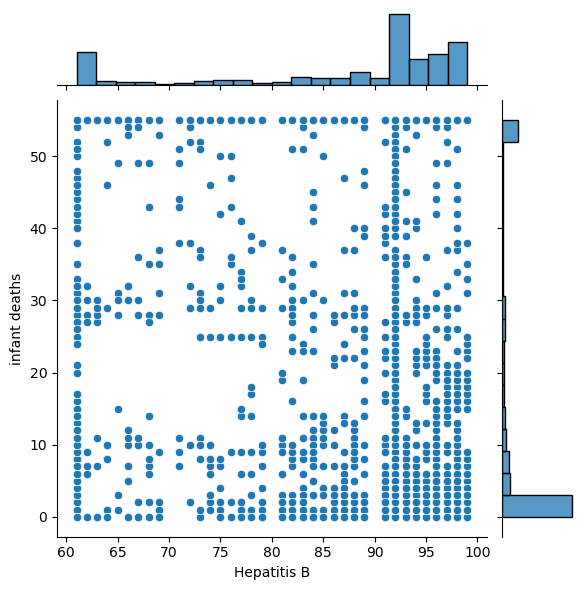

In [80]:
sns.jointplot(x='Hepatitis B', y='infant deaths', data=kk)

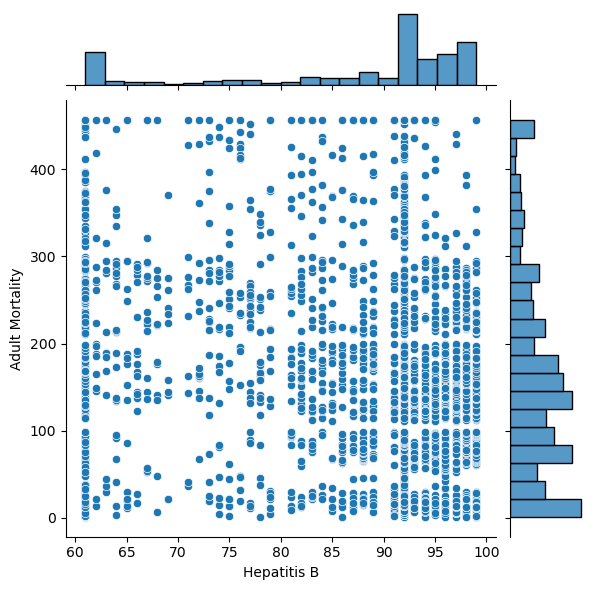

In [81]:
sns.jointplot(x='Hepatitis B', y='Adult Mortality', data=kk)

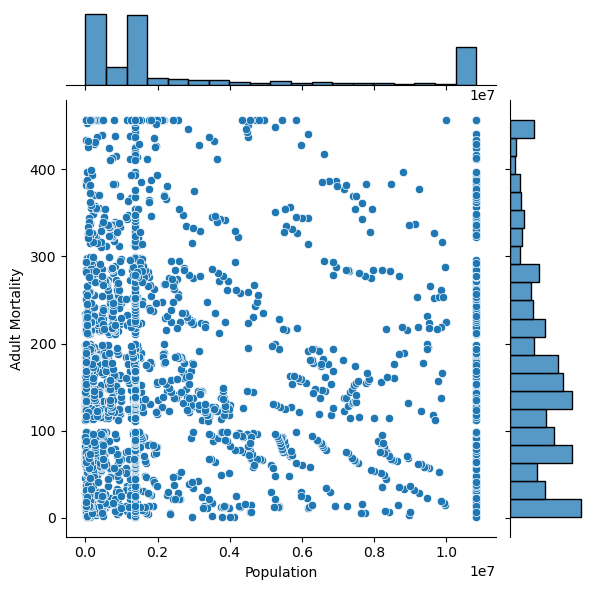

In [82]:
sns.jointplot(x='Population', y='Adult Mortality', data=kk)

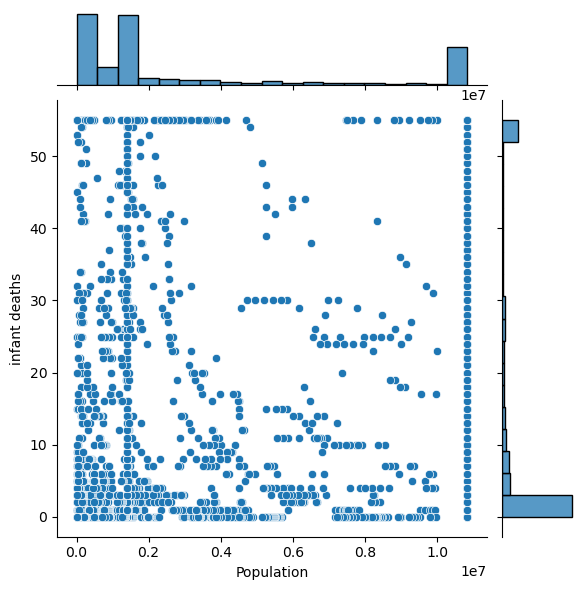

In [83]:
sns.jointplot(x='Population', y='infant deaths', data=kk)

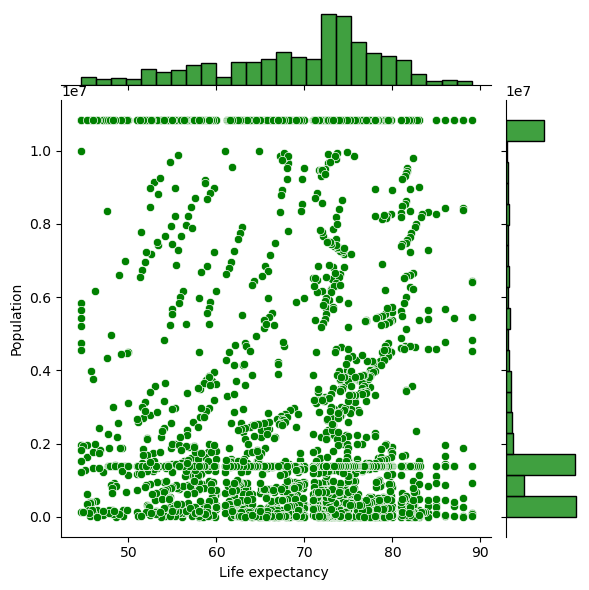

In [84]:
sns.jointplot(x='Life expectancy ', y='Population', data=kk, color = 'green', kind = 'scatter')

<Axes: xlabel='count', ylabel='Year'>

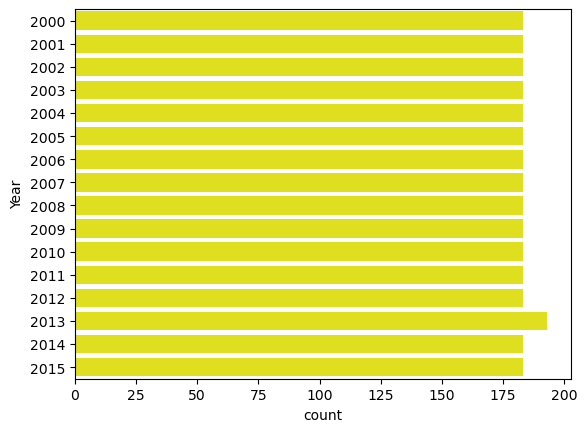

In [85]:
sns.countplot(y="Year", data = kk, color='yellow')

<Axes: xlabel='count', ylabel='Country'>

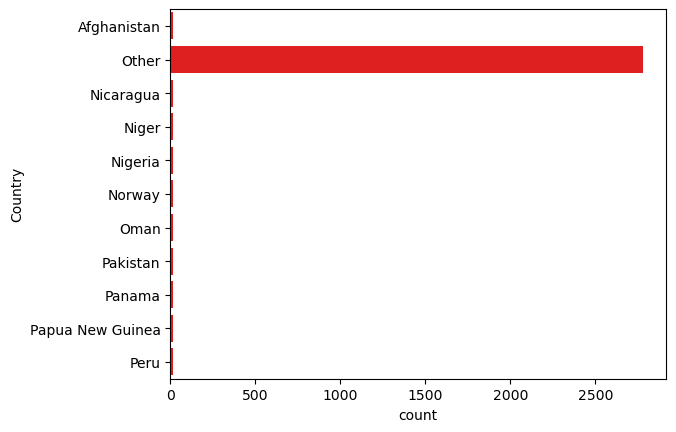

In [86]:
sns.countplot(y="Country", data = kk, color='red')

<Axes: xlabel='Status', ylabel='count'>

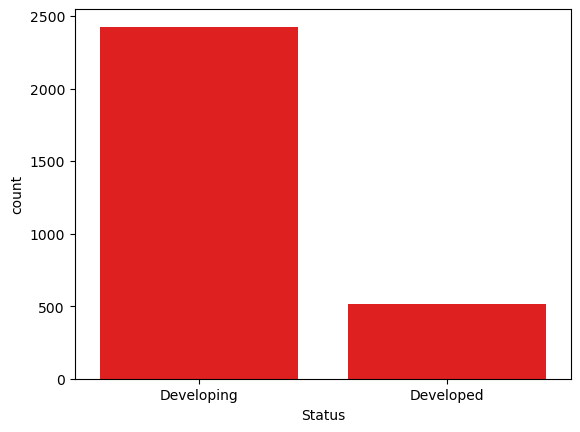

In [87]:
sns.countplot(x="Status", data = kk, color='red')

In [88]:
kk.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,55,0.01,71.279624,65.0,900.625,...,49.5,8.16,65.0,0.1,584.259210,10832552.25,15.35,15.6,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,55,0.01,73.523582,62.0,492.000,...,58.0,8.18,62.0,0.1,612.696514,327582.00,15.35,15.6,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,55,0.01,73.219243,64.0,430.000,...,62.0,8.13,64.0,0.1,631.744976,10832552.25,15.35,15.6,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,55,0.01,78.184215,67.0,900.625,...,67.0,8.52,67.0,0.1,669.959000,3696958.00,15.35,15.6,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,55,0.01,7.097109,68.0,900.625,...,68.0,7.87,68.0,0.1,63.537231,2978599.00,15.35,15.6,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,55,0.01,79.679367,66.0,900.625,...,66.0,9.20,66.0,0.1,553.328940,2883167.00,15.35,15.6,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,55,0.01,56.762217,63.0,900.625,...,63.0,9.42,63.0,0.1,445.893298,284331.00,15.35,15.6,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,55,0.03,25.873925,64.0,900.625,...,64.0,8.33,64.0,0.1,373.361116,2729431.00,15.35,15.6,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,55,0.02,10.910156,63.0,900.625,...,63.0,6.73,63.0,0.1,369.835796,10832552.25,15.35,15.6,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,55,0.03,17.171518,64.0,900.625,...,58.0,7.43,58.0,0.1,272.563770,2589345.00,15.35,15.6,0.405,8.1


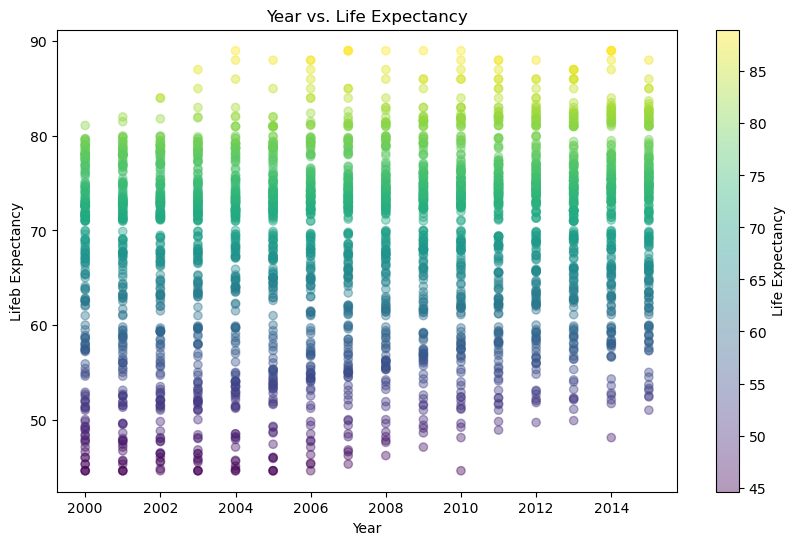

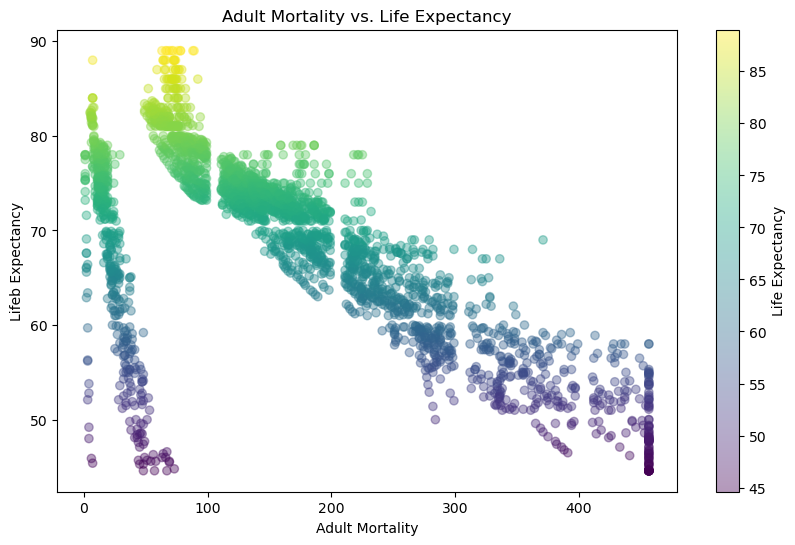

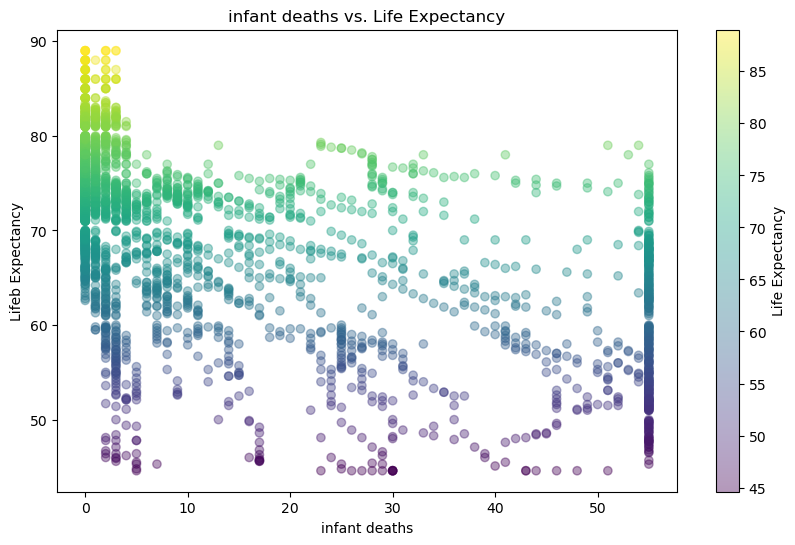

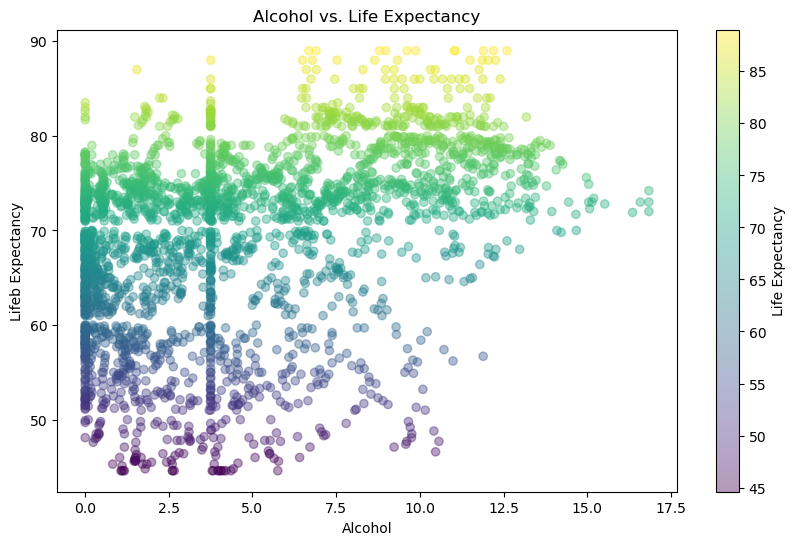

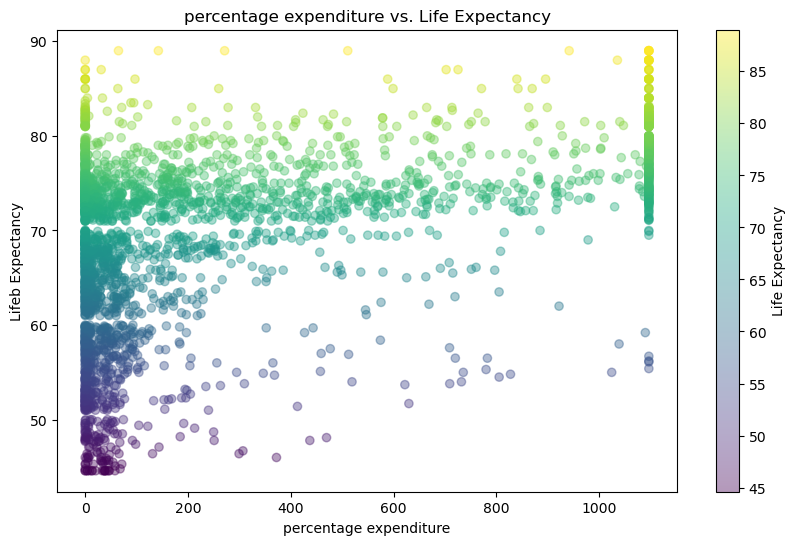

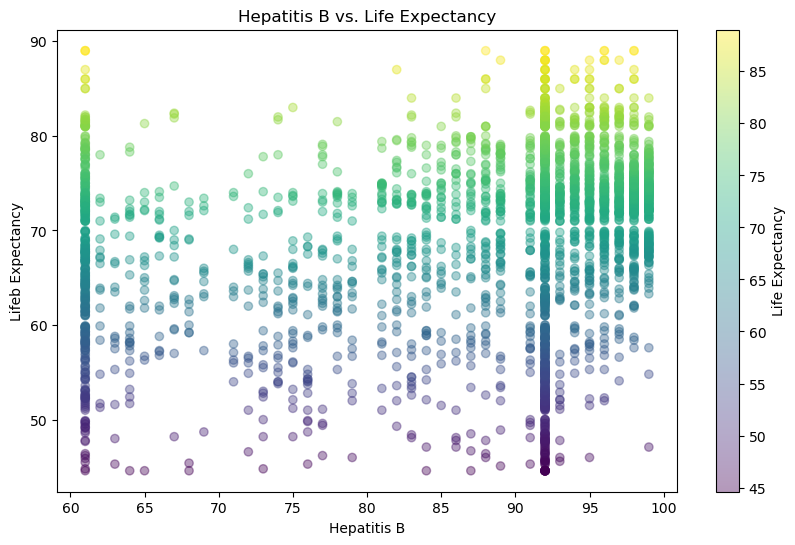

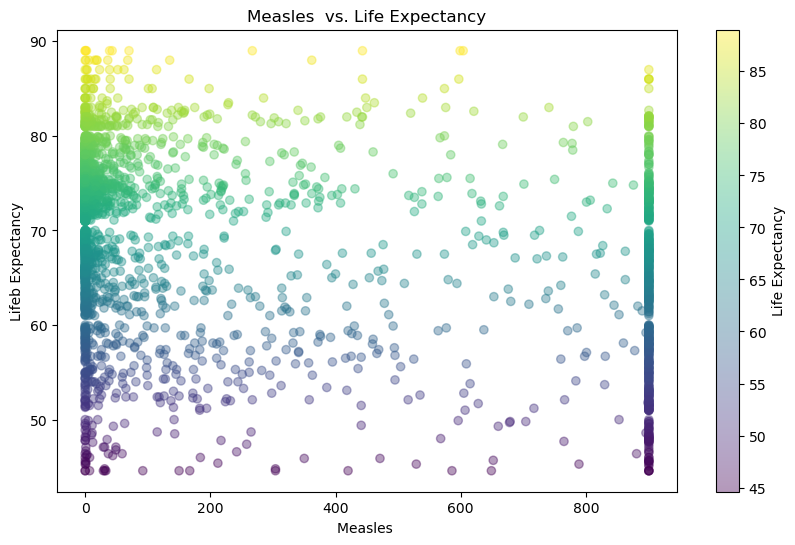

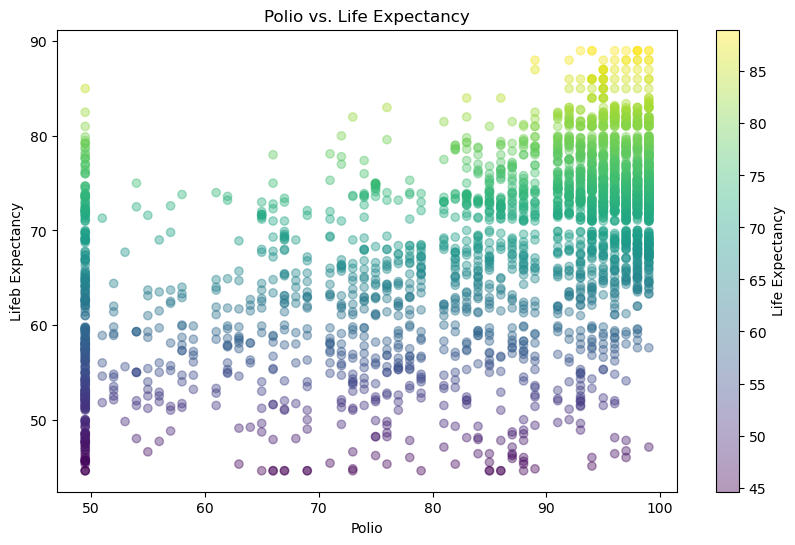

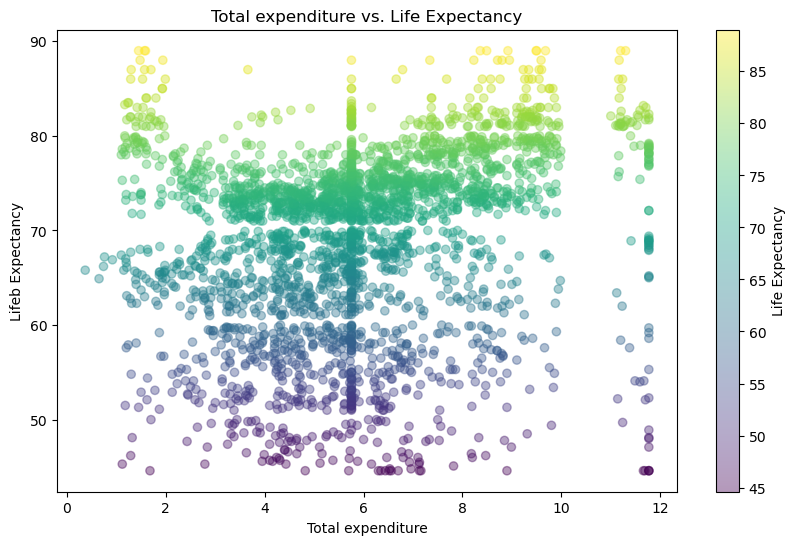

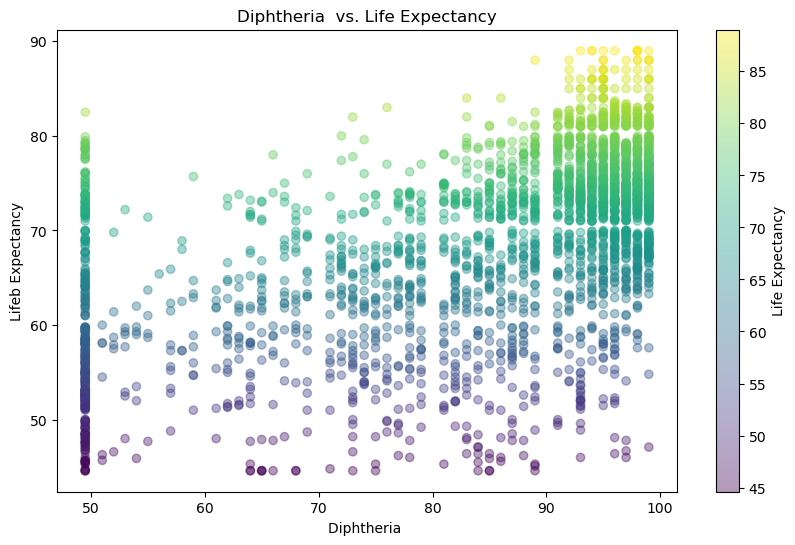

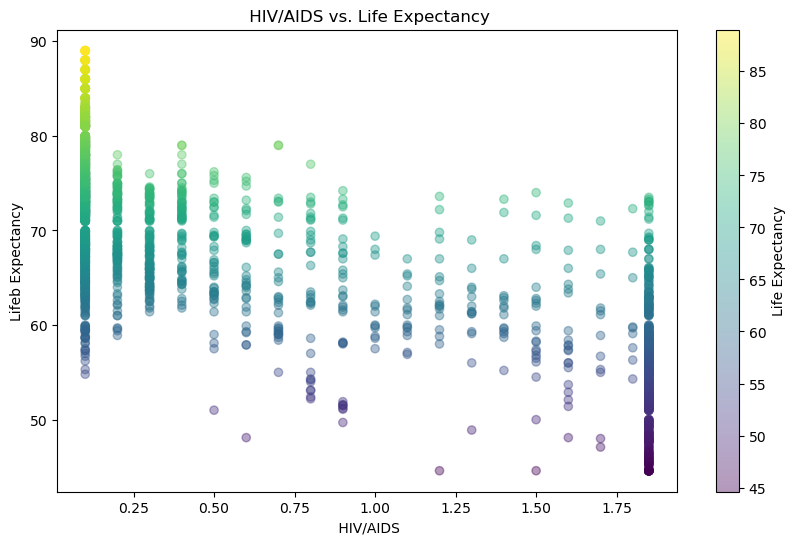

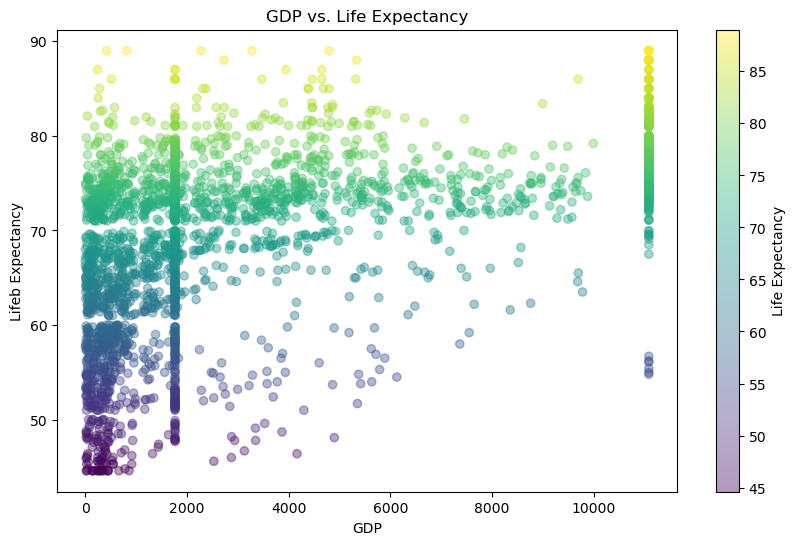

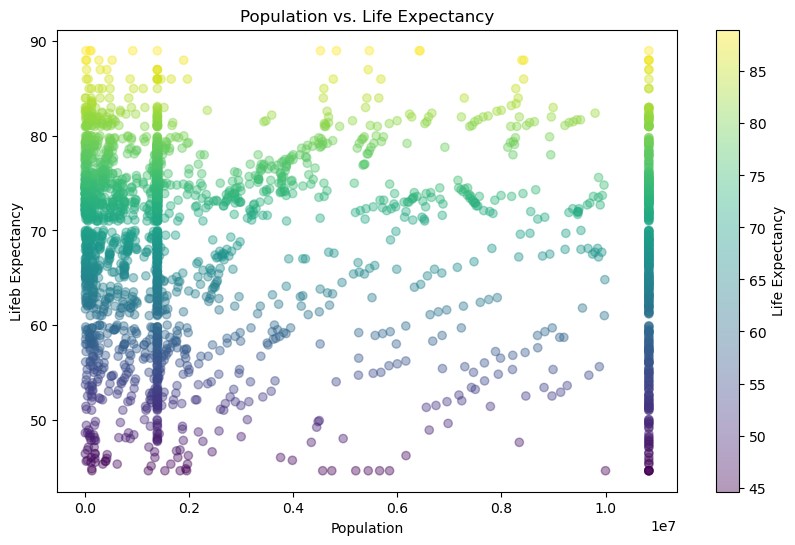

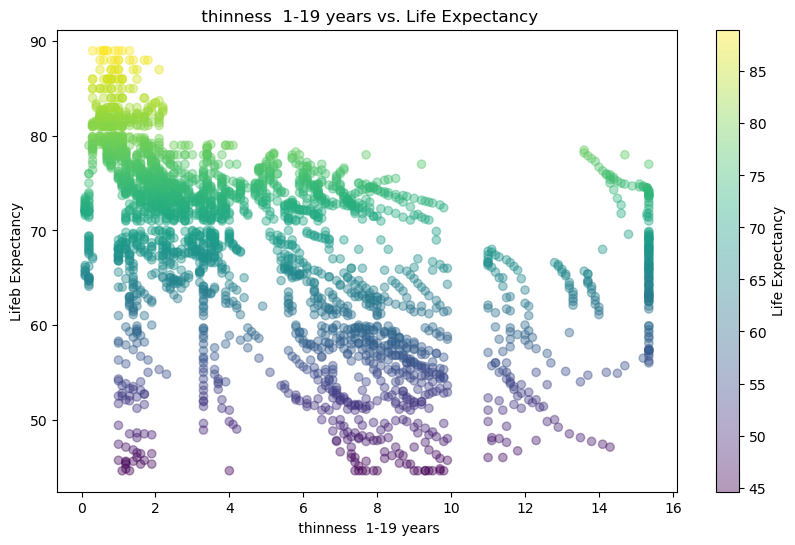

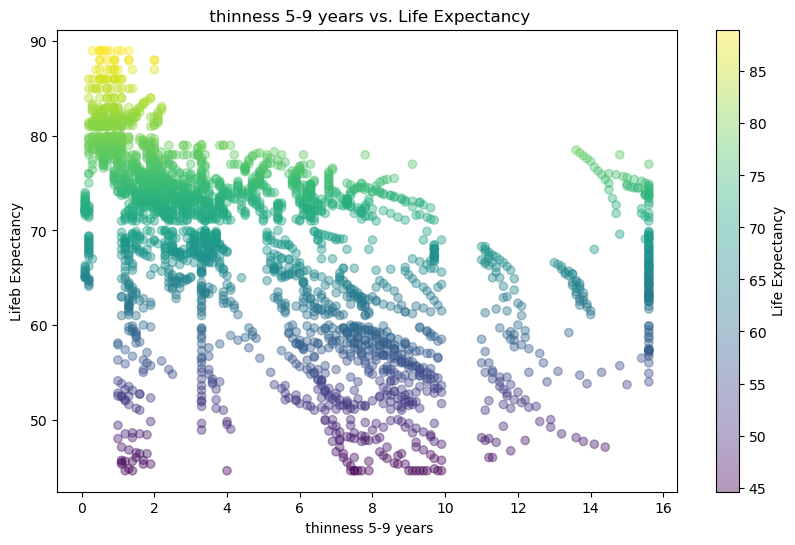

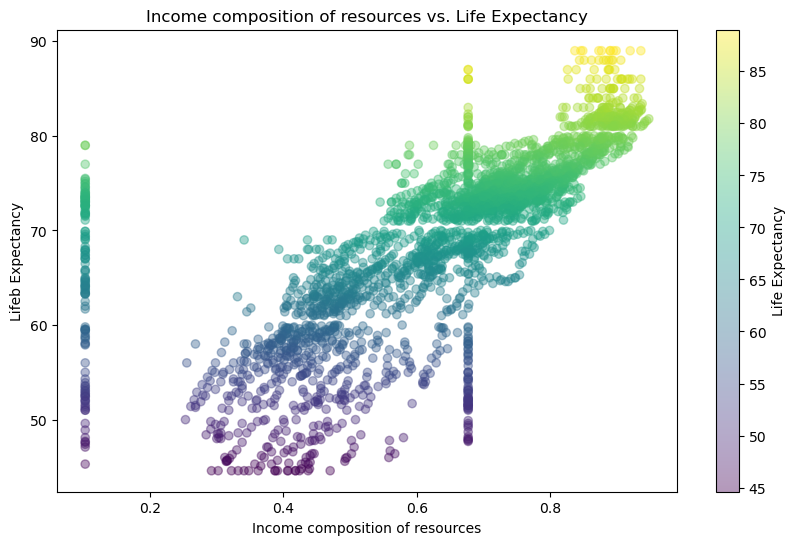

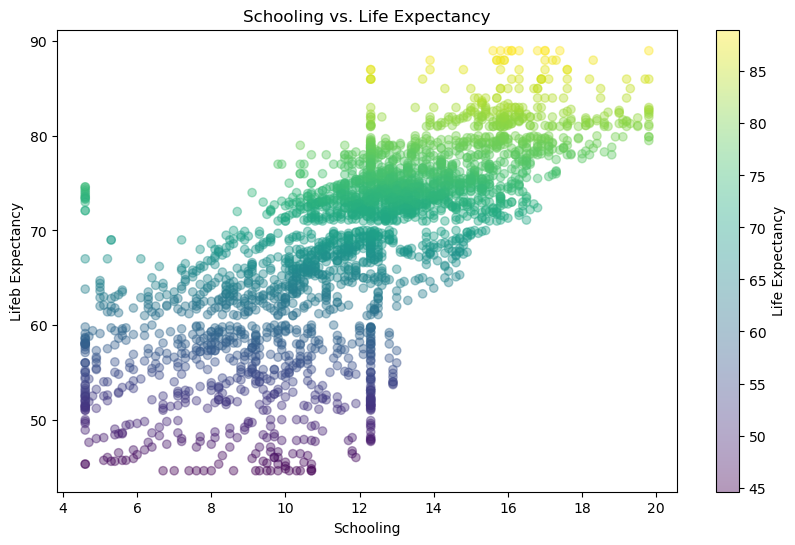

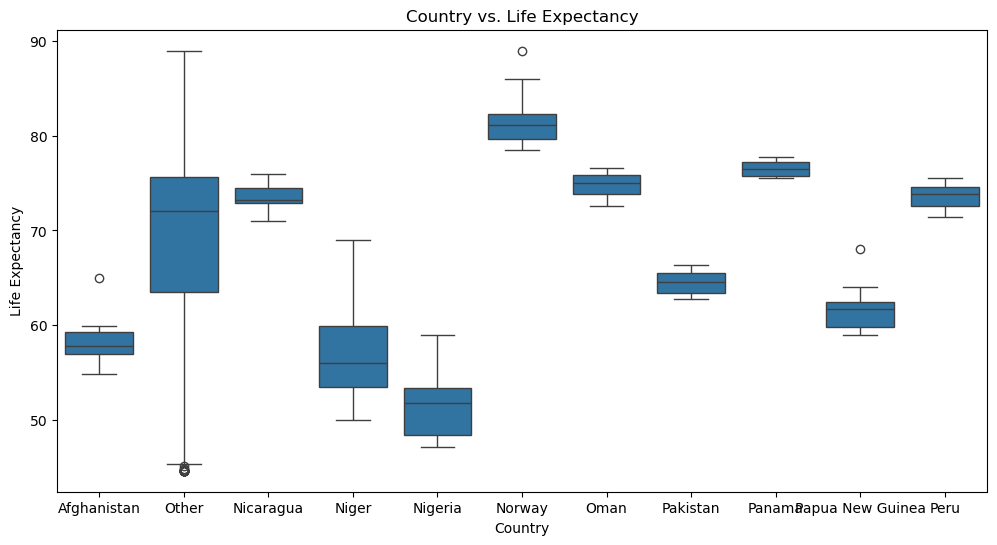

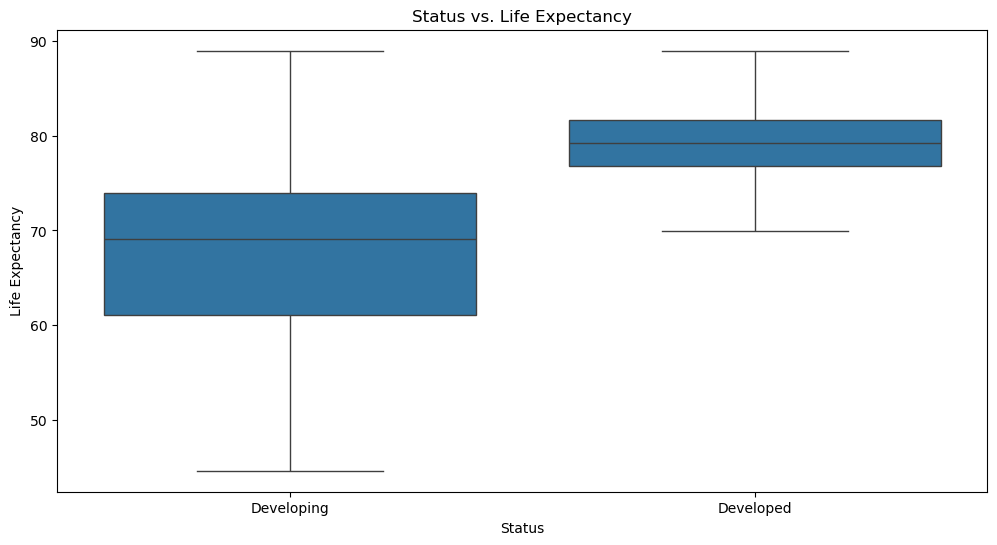

In [89]:
 # Function to plot numerical columns against median_house_value
def plot_numerical(kk, column):
    plt.figure(figsize=(10, 6))
    plt.scatter(kk[column], kk['Life expectancy '], alpha=0.4, c=kk['Life expectancy '], cmap='viridis')
    plt.xlabel(column)
    plt.ylabel('Lifeb Expectancy')
    plt.title(f'{column} vs. Life Expectancy')
    plt.colorbar(label='Life Expectancy')
    plt.show()

# Function to plot categorical columns against Life expectancy
def plot_categorical(kk, column):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=column, y='Life expectancy ', data=kk)
    plt.xlabel(column)
    plt.ylabel('Life Expectancy')
    plt.title(f'{column} vs. Life Expectancy')
    plt.show()

# Visualize numerical columns
numerical_columns = ['Year', 'Adult Mortality',	'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', 'Polio',	'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

for column in numerical_columns:
    plot_numerical(kk, column)

# Visualize categorical columns
categorical_columns = ['Country', 'Status']

for column in categorical_columns:
    plot_categorical(kk, column)


In [90]:

for column in kk.select_dtypes(include = 'object').columns:

    encoder = LabelEncoder()
    encoder_data = encoder.fit_transform(kk[column])
    kk[column] = encoder_data
print(encoder_data)

[1 1 1 ... 1 1 1]


In [91]:
kk.head(20)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,2015,1,65.0,263.0,55,0.01,71.279624,65.0,900.625,...,49.5,8.16,65.0,0.1,584.259210,10832552.25,15.35,15.6,0.479,10.1
1,0,2014,1,59.9,271.0,55,0.01,73.523582,62.0,492.000,...,58.0,8.18,62.0,0.1,612.696514,327582.00,15.35,15.6,0.476,10.0
2,0,2013,1,59.9,268.0,55,0.01,73.219243,64.0,430.000,...,62.0,8.13,64.0,0.1,631.744976,10832552.25,15.35,15.6,0.470,9.9
3,0,2012,1,59.5,272.0,55,0.01,78.184215,67.0,900.625,...,67.0,8.52,67.0,0.1,669.959000,3696958.00,15.35,15.6,0.463,9.8
4,0,2011,1,59.2,275.0,55,0.01,7.097109,68.0,900.625,...,68.0,7.87,68.0,0.1,63.537231,2978599.00,15.35,15.6,0.454,9.5
5,0,2010,1,58.8,279.0,55,0.01,79.679367,66.0,900.625,...,66.0,9.20,66.0,0.1,553.328940,2883167.00,15.35,15.6,0.448,9.2
6,0,2009,1,58.6,281.0,55,0.01,56.762217,63.0,900.625,...,63.0,9.42,63.0,0.1,445.893298,284331.00,15.35,15.6,0.434,8.9
7,0,2008,1,58.1,287.0,55,0.03,25.873925,64.0,900.625,...,64.0,8.33,64.0,0.1,373.361116,2729431.00,15.35,15.6,0.433,8.7
8,0,2007,1,57.5,295.0,55,0.02,10.910156,63.0,900.625,...,63.0,6.73,63.0,0.1,369.835796,10832552.25,15.35,15.6,0.415,8.4
9,0,2006,1,57.3,295.0,55,0.03,17.171518,64.0,900.625,...,58.0,7.43,58.0,0.1,272.563770,2589345.00,15.35,15.6,0.405,8.1


<Axes: >

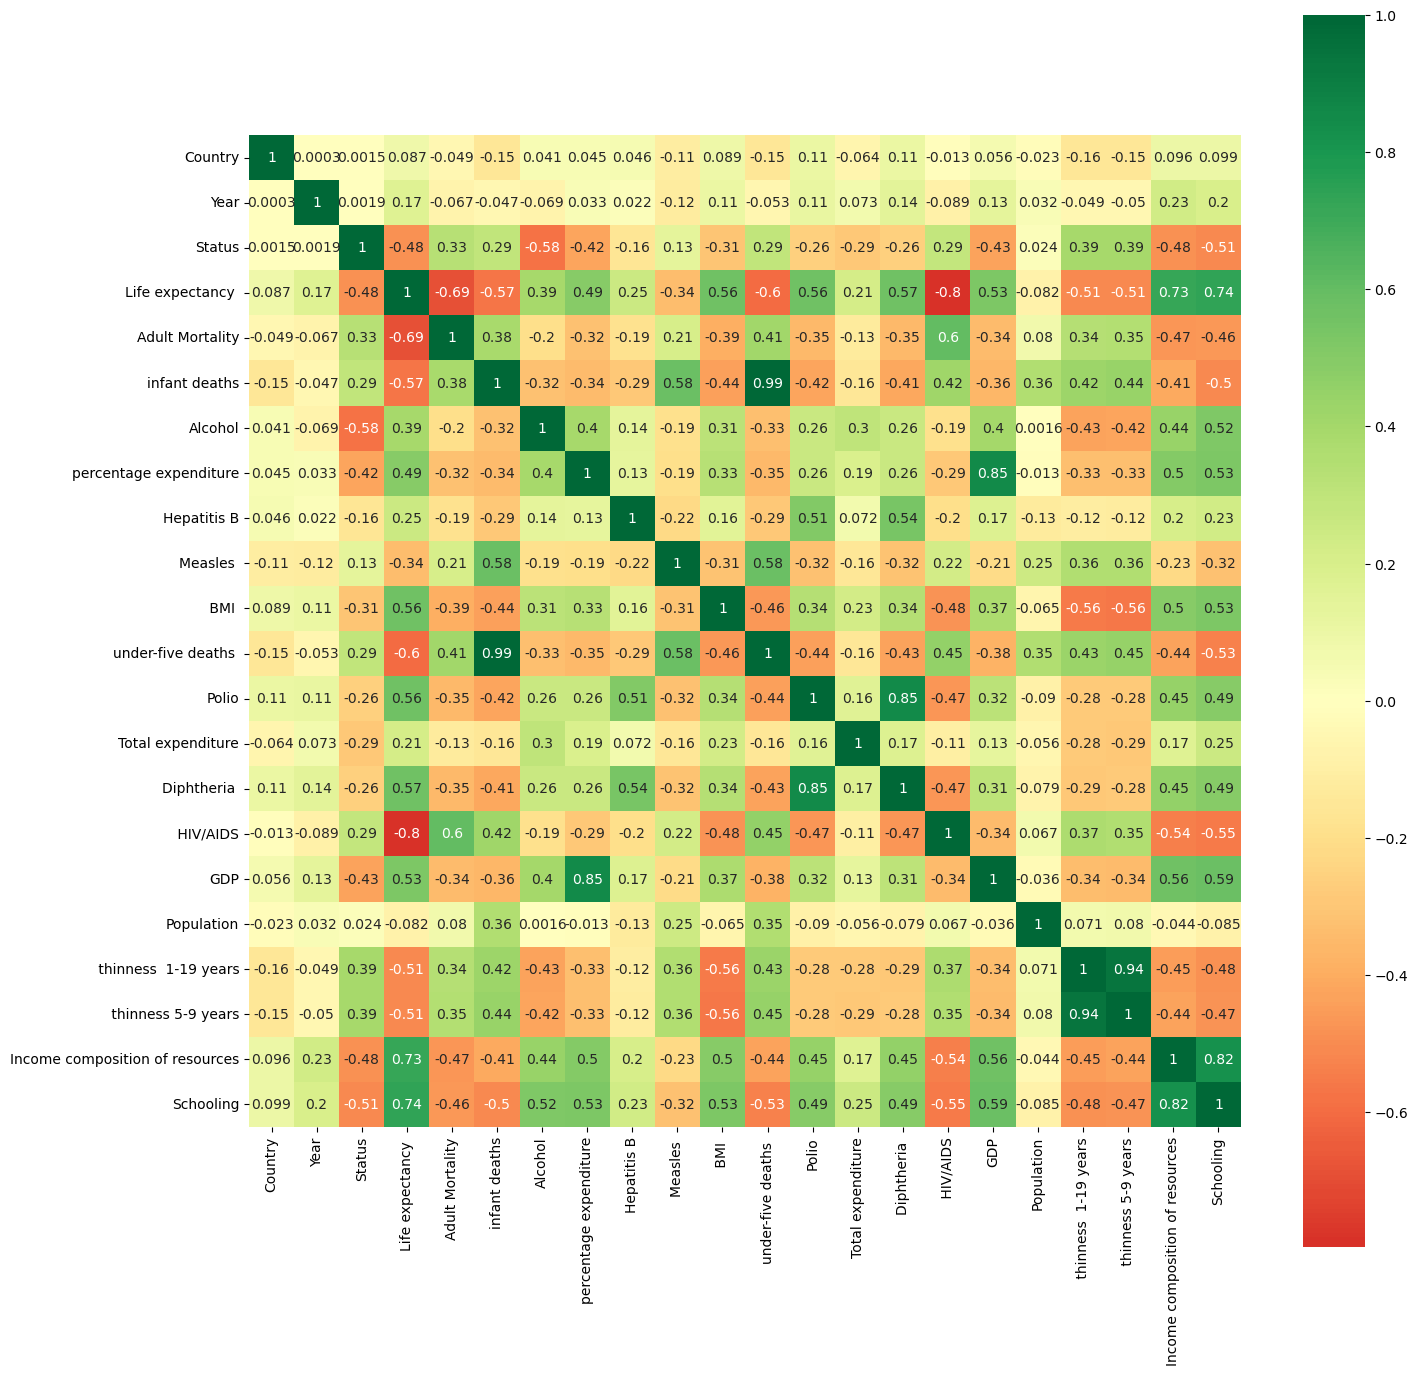

In [92]:
plt.figure(figsize = (16, 16))
# Plot the correlation matrix as a heatmap
sns.heatmap(kk.corr(), annot=True, cmap='RdYlGn', center=0, square=True)

In [93]:
print(kk.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')


In [94]:
# List of columns to drop
columns_to_drop = ['Country', 'Year', 'Status']  # Replace with actual column names

# Drop the columns
kk = kk.drop(columns=columns_to_drop)

# Verify the columns have been dropped
print(kk.head())

   Life expectancy   Adult Mortality  infant deaths  Alcohol  \
0              65.0            263.0             55     0.01   
1              59.9            271.0             55     0.01   
2              59.9            268.0             55     0.01   
3              59.5            272.0             55     0.01   
4              59.2            275.0             55     0.01   

   percentage expenditure  Hepatitis B  Measles    BMI   under-five deaths   \
0               71.279624         65.0   900.625   19.1                  70   
1               73.523582         62.0   492.000   18.6                  70   
2               73.219243         64.0   430.000   18.1                  70   
3               78.184215         67.0   900.625   17.6                  70   
4                7.097109         68.0   900.625   17.2                  70   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP   Population  \
0   49.5               8.16         65.0        0.1  584.259

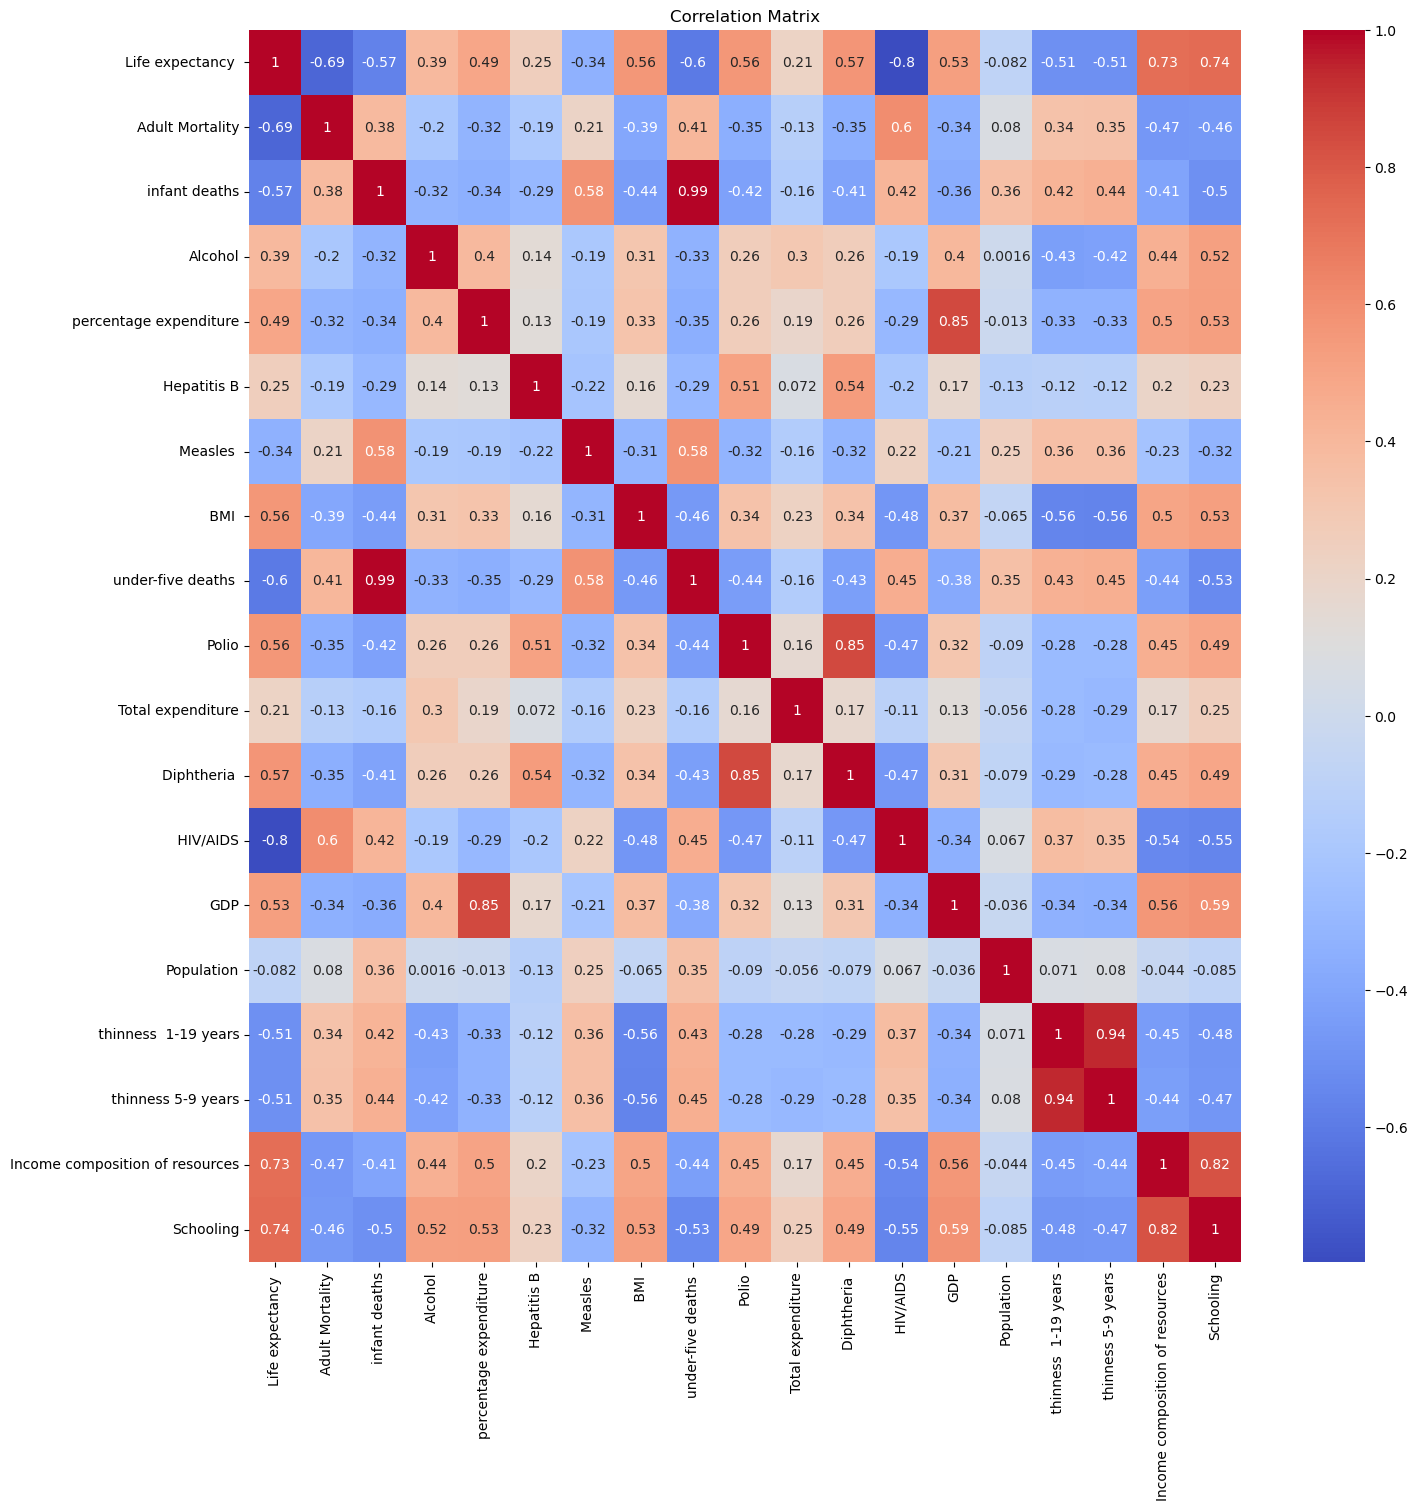

In [95]:
plt.figure(figsize = (16, 16))
# Plot a heatmap to visualize the correlation matrix using seaborn
sns.heatmap(kk.corr(), annot=True, cmap='coolwarm')

# Add a title to the plot           
plt.title('Correlation Matrix')

# Display the plot            
plt.show()

# Regression 
- Linear Regression

# Introducing the dependent variables (response variables Y) and the independent variables (predictor variable X)

In [96]:
y = kk['Life expectancy ']
X = kk[['Population']]

In [97]:
lm2 = LinearRegression()

In [98]:
lm2.fit(X,y)

LinearRegression()

In [99]:
print(lm2.intercept_, lm2.coef_)

69.88921150919528 [-2.03142639e-07]


In [100]:
y_pred1 = lm2.predict(X)

In [101]:
r2_score(y, y_pred1)

0.00676076151703342

# Multiple Linear Regression

In [102]:
y = kk['Life expectancy ']
x = kk.drop("Life expectancy ",axis=1)

In [103]:
lr = LinearRegression()

In [104]:
lr.fit(x,y)

LinearRegression()

In [105]:
lr.intercept_, lr.coef_

(62.45930280609218,
 array([-1.67322249e-02,  2.53525499e-01,  6.35863928e-02,  1.47136429e-03,
        -3.14473820e-02, -7.89693423e-07,  6.14376406e-05, -2.45811125e-01,
         2.39638913e-02,  1.00736278e-01,  5.26795742e-02, -4.84015621e+00,
         4.57704497e-05,  7.82742470e-08,  2.67301554e-02, -1.63304509e-01,
         8.00981514e+00,  2.56710164e-01]))

In [106]:
y_pred = lr.predict(x)

In [107]:
r2_score(y, y_pred)

0.8504447719238846

# prediction = 85%

# Saving the Clean dataset

In [108]:
kk.to_csv("Cleaned_Life expectancy Dataset.csv", index = False)

# Spliting the data to Test and Train to evaluatee the performanceof a model on unseen data

In [109]:
from sklearn.model_selection import train_test_split

In [110]:
#Load the dataset:
kk = pd.read_csv("Cleaned_Life expectancy Dataset.csv",)

In [111]:
kk.head(20)

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,65.0,263.0,55,0.01,71.279624,65.0,900.625,19.1,70,49.5,8.16,65.0,0.1,584.259210,10832552.25,15.35,15.6,0.479,10.1
1,59.9,271.0,55,0.01,73.523582,62.0,492.000,18.6,70,58.0,8.18,62.0,0.1,612.696514,327582.00,15.35,15.6,0.476,10.0
2,59.9,268.0,55,0.01,73.219243,64.0,430.000,18.1,70,62.0,8.13,64.0,0.1,631.744976,10832552.25,15.35,15.6,0.470,9.9
3,59.5,272.0,55,0.01,78.184215,67.0,900.625,17.6,70,67.0,8.52,67.0,0.1,669.959000,3696958.00,15.35,15.6,0.463,9.8
4,59.2,275.0,55,0.01,7.097109,68.0,900.625,17.2,70,68.0,7.87,68.0,0.1,63.537231,2978599.00,15.35,15.6,0.454,9.5
5,58.8,279.0,55,0.01,79.679367,66.0,900.625,16.7,70,66.0,9.20,66.0,0.1,553.328940,2883167.00,15.35,15.6,0.448,9.2
6,58.6,281.0,55,0.01,56.762217,63.0,900.625,16.2,70,63.0,9.42,63.0,0.1,445.893298,284331.00,15.35,15.6,0.434,8.9
7,58.1,287.0,55,0.03,25.873925,64.0,900.625,15.7,70,64.0,8.33,64.0,0.1,373.361116,2729431.00,15.35,15.6,0.433,8.7
8,57.5,295.0,55,0.02,10.910156,63.0,900.625,15.2,70,63.0,6.73,63.0,0.1,369.835796,10832552.25,15.35,15.6,0.415,8.4
9,57.3,295.0,55,0.03,17.171518,64.0,900.625,14.7,70,58.0,7.43,58.0,0.1,272.563770,2589345.00,15.35,15.6,0.405,8.1


In [112]:
X = kk.drop("Life expectancy ", axis=1)
y = kk['Life expectancy ']

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In this example, we are splitting the data into a training set (80% of the data) and a test set (20% of the data). The random_state parameter ensures reproducibility of the split

In [114]:
X_train.shape

(2350, 18)

In [115]:
X_test.shape

(588, 18)

# Performing Linear Regression for the Train & Test data

In [116]:
lr = LinearRegression()

In [117]:
lr.fit(X_train,y_train)

LinearRegression()

In [118]:
y_pred = lr.predict(X_train)

In [119]:
r2_score(y_train, y_pred)

0.8481057850298009

# Predicting Value for the train data is 84%

In [120]:
y_test_pred = lr.predict(X_test)

In [121]:
r2_score(y_test, y_test_pred)

0.8579429135472225

# Predicting Value for the test data is 85%¶